In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Chargement du dataset et affichage des première lignes

In [56]:
dataset_path = Path("../dataset/predictive_maintenance_v3.csv")
df = pd.read_csv(dataset_path)

In [57]:
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [58]:
df.shape

(24042, 15)

# 2. Valeurs manquantes

In [59]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Manquantes': missing.values,
    'Pourcentage': missing_pct.values
})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Manquantes', ascending=False)

In [60]:
missing_df

,Colonne,Manquantes,Pourcentage
3,vibration_rms,1000,4.159388
6,pressure_level,924,3.843274
4,temperature_motor,834,3.468929
5,current_phase_avg,731,3.040512
7,rpm,533,2.216954


# 3. Informations générales

In [61]:
df.describe().round(3)

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000,23042.000,23208.000,23311.000,23118.000,23509.000,24042.000,24042.000,24042.000,24042.000,24042.000
mean,10.505,1.624,51.404,8.824,59.012,1144.849,172.631,12.996,27.813,0.148,608.870
std,5.746,1.081,12.519,5.366,38.723,912.671,150.722,2.884,26.394,0.355,1566.794
min,1.000,0.350,28.000,2.200,10.100,124.100,0.000,8.000,0.500,0.000,0.000
25%,6.000,0.820,42.610,4.630,22.700,489.400,42.870,10.500,0.500,0.000,0.000
50%,10.000,1.270,50.060,6.430,46.300,856.000,121.610,13.000,22.570,0.000,0.000
75%,15.000,2.270,59.962,13.120,94.700,1676.000,295.575,15.500,46.410,0.000,0.000
max,20.000,10.000,95.000,35.000,206.500,4098.800,575.630,18.000,98.340,1.000,7995.000


# 4. Distribution de la classe cible

In [62]:
print("\n" + "=" * 80)
print("Distribution de la classe 'failure_within_24h'")
class_dist = df['failure_within_24h'].value_counts()
class_pct = df['failure_within_24h'].value_counts(normalize=True) * 100
print(f"No Failure: {class_dist[0]:,} ({class_pct[0]:.2f}%)")
print(f"Failure:    {class_dist[1]:,} ({class_pct[1]:.2f}%)")


Distribution de la classe 'failure_within_24h'
No Failure: 20,482 (85.19%)
Failure:    3,560 (14.81%)


# 5. Distribution des classes catégorielles

In [63]:
print("\n" + "=" * 80)
print("Distribution des modes opératoires")
print(df['operating_mode'].value_counts())

print("\n" + "=" * 80)
print("Distribution des types de machines")
print(df['machine_type'].value_counts())

print("\n" + "=" * 80)
print("Distribution des types de défaillances")
print(df['failure_type'].value_counts())


Distribution des modes opératoires
operating_mode
normal    11632
idle      10862
peak       1548
Name: count, dtype: int64

Distribution des types de machines
machine_type
Pump           6114
Robotic Arm    6003
Compressor     5988
CNC            5937
Name: count, dtype: int64

Distribution des types de défaillances
failure_type
none              20482
bearing            1117
motor_overheat     1060
hydraulic           728
electrical          655
Name: count, dtype: int64


# 6. Distribution des classes numériques

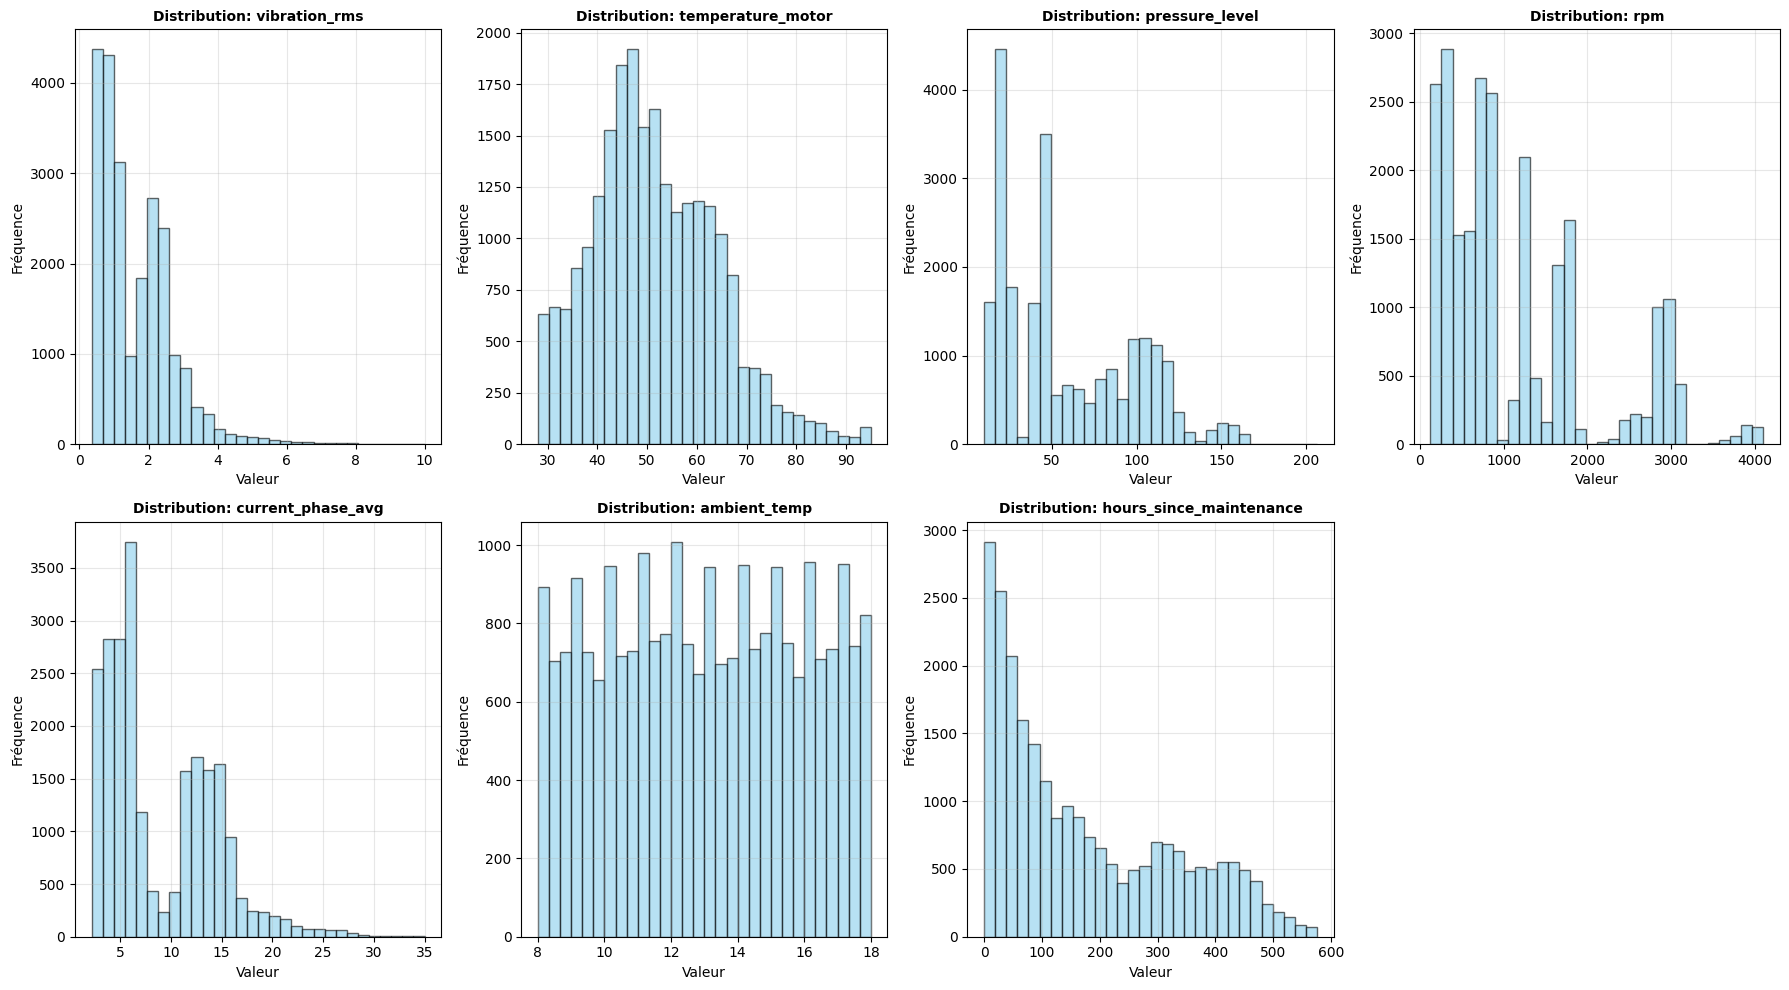

In [64]:
sensors = ['vibration_rms', 'temperature_motor', 'pressure_level', 'rpm', 
           'current_phase_avg', 'ambient_temp', 'hours_since_maintenance']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, sensor in enumerate(sensors):
    # Histogramme + KDE
    axes[idx].hist(df[sensor].dropna(), bins=30, alpha=0.6, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution: {sensor}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Valeur')
    axes[idx].set_ylabel('Fréquence')
    axes[idx].grid(True, alpha=0.3)

axes[-1].remove()

plt.tight_layout()
plt.show()

# 7. Corrélations et Relation

Corrélation avec la variable cible (failure_within_24h):
failure_within_24h         1.000000
estimated_repair_cost      0.932144
temperature_motor          0.385782
vibration_rms              0.263821
current_phase_avg          0.156709
hours_since_maintenance    0.099519
machine_id                 0.012657
pressure_level             0.012635
ambient_temp               0.003907
rpm                       -0.024159
rul_hours                 -0.253235
Name: failure_within_24h, dtype: float64


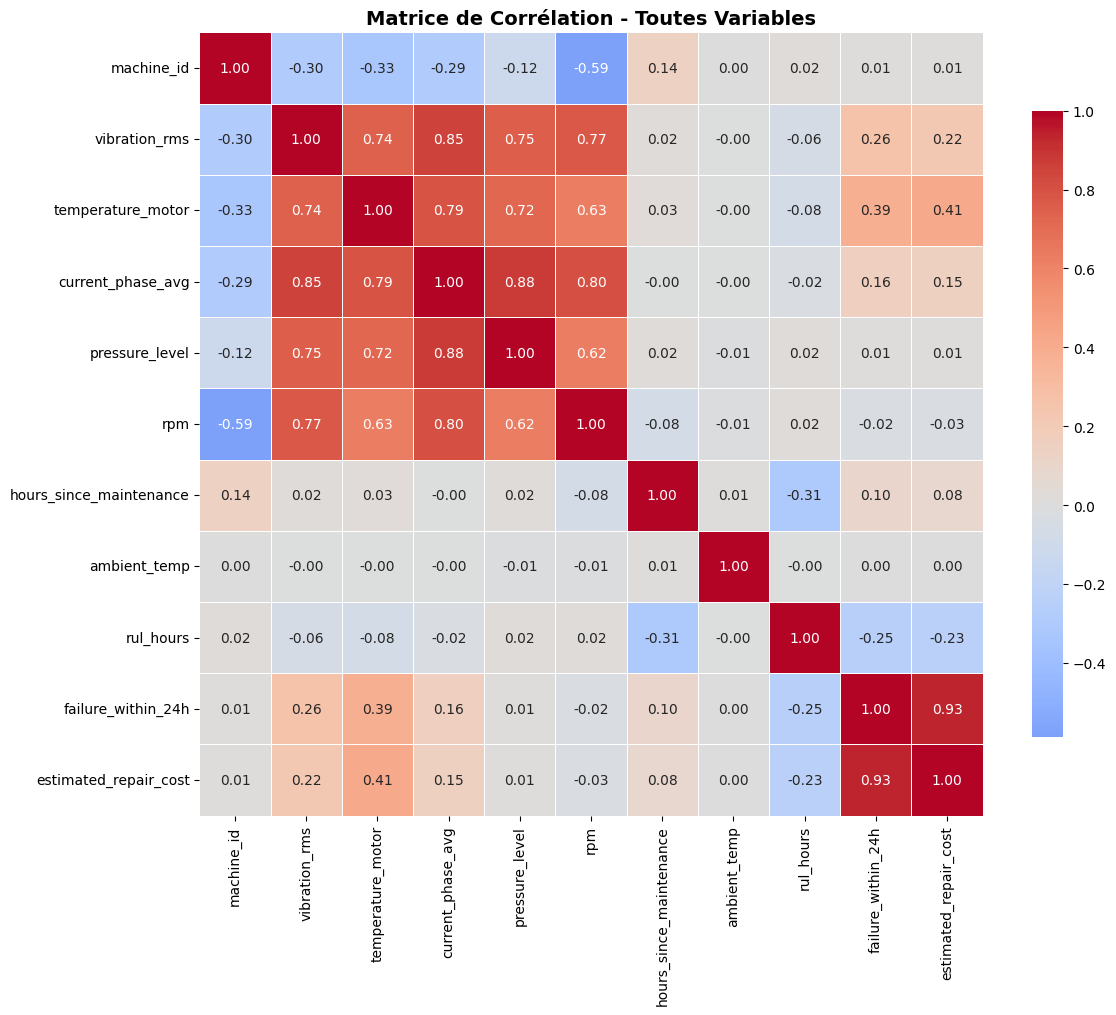

In [65]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

print("Corrélation avec la variable cible (failure_within_24h):")
target_corr = corr_matrix['failure_within_24h'].sort_values(ascending=False)
print(target_corr)

# Heatmap de corrélation
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matrice de Corrélation - Toutes Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 8. Distribution des valeurs des capteurs pour la variable cible

/var/folders/fr/dfzt21v96172hc77ylkj46yh0000gn/T/ipykernel_39945/4233500141.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['No Failure', 'Failure'])
/var/folders/fr/dfzt21v96172hc77ylkj46yh0000gn/T/ipykernel_39945/4233500141.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['No Failure', 'Failure'])
/var/folders/fr/dfzt21v96172hc77ylkj46yh0000gn/T/ipykernel_39945/4233500141.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_to_plot, labels=['No Failure', 'Failure'])
/var/folders/fr/dfzt21v96172hc77ylkj46yh000

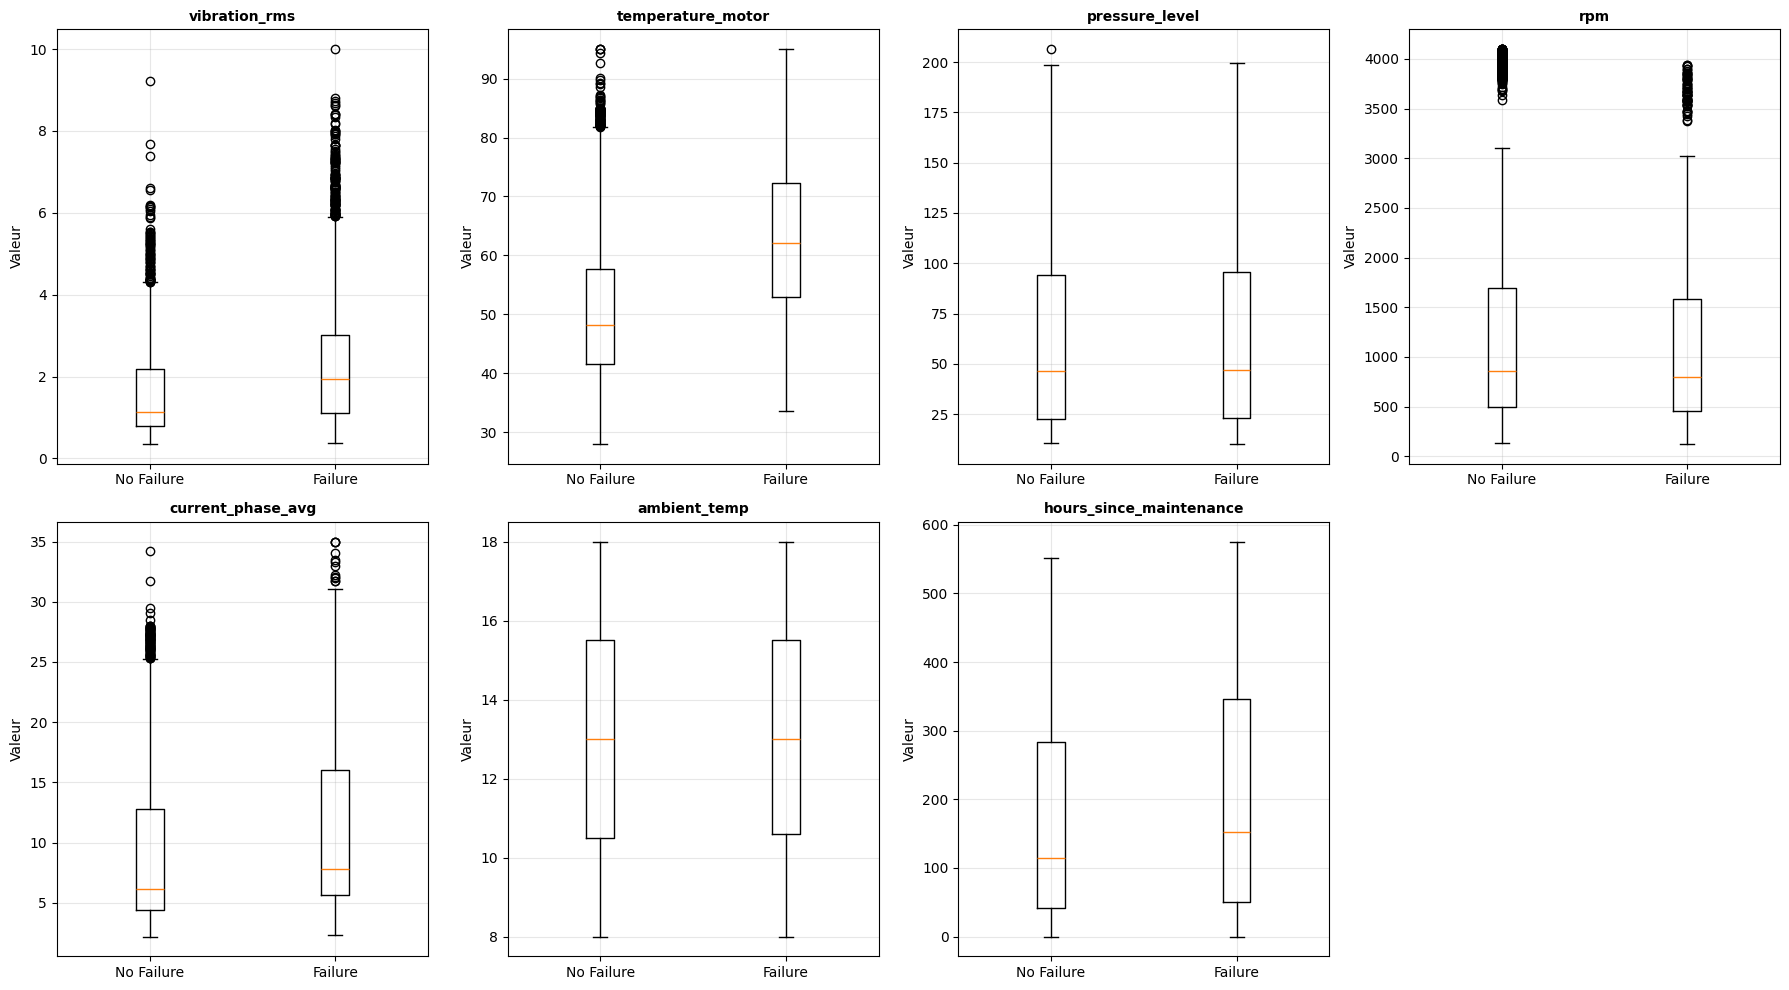

In [66]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, sensor in enumerate(sensors):
    data_to_plot = [df[df['failure_within_24h'] == 0][sensor].dropna(),
                    df[df['failure_within_24h'] == 1][sensor].dropna()]
    axes[idx].boxplot(data_to_plot, labels=['No Failure', 'Failure'])
    axes[idx].set_title(f'{sensor}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Valeur')
    axes[idx].grid(True, alpha=0.3)

axes[-1].remove()

plt.tight_layout()
plt.show()